##Finding the best value of K for the KNN model using cross-validation on the Iris Dataset.

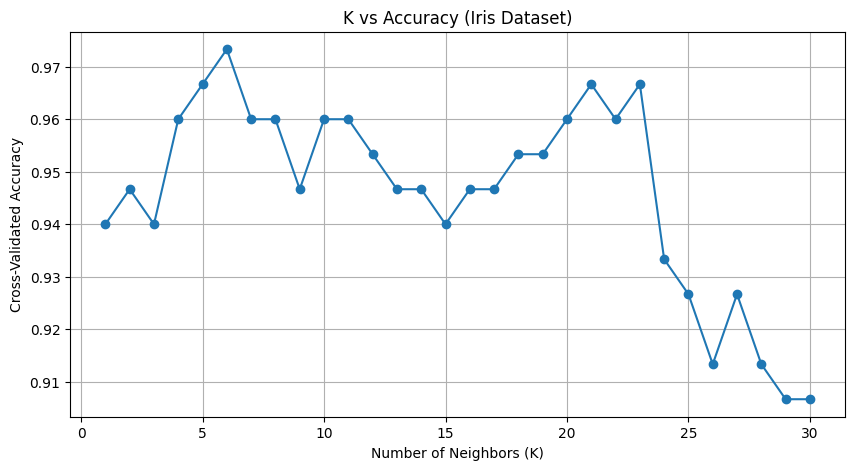

Best K: 6 with Accuracy: 0.973


In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import matplotlib.pyplot as plt

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K values to test
k_range = range(1, 31)  # test 1 to 30 neighbors
accuracy_list = []

# Use 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#StratifiedKFold keeps same class proportions in each fold, If dataset has class imbalance, so we are using it instead of normal KFold.

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2)  # Euclidean
    scores = cross_val_score(knn, X_scaled, y, cv=skf)
    accuracy_list.append(scores.mean())

# Plot accuracy vs K
plt.figure(figsize=(10,5))
plt.plot(k_range, accuracy_list, marker='o')
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Cross-Validated Accuracy")
plt.title("K vs Accuracy (Iris Dataset)")
plt.grid(True)
plt.show()

# Best K
best_k = k_range[np.argmax(accuracy_list)]
print("Best K:", best_k, "with Accuracy:", round(max(accuracy_list), 3))

#np.argmax() finds the index of maximum accuracy.


accuracy_list = [0.94,0.95,0.96,0.95]
max accuracy → 0.96

Corresponding K → 3

In [ ]:
# Train KNN on the entire dataset using best K
knn_final = KNeighborsClassifier(n_neighbors=best_k, metric='minkowski', p=2)
knn_final.fit(X_scaled, y)

# Example: classify a new flower
new_flower = np.array([[5.5, 2.6, 4.4, 1.2]])  # Sepal L, Sepal W, Petal L, Petal W
new_flower_scaled = scaler.transform(new_flower)  # scale features
predicted_class = knn_final.predict(new_flower_scaled)
predicted_species = iris.target_names[predicted_class]

#iris.target_names contains: ['setosa', 'versicolor', 'virginica']

print("The new flower is predicted as:", predicted_species)


The new flower is predicted as: ['versicolor']
